In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la
from scipy.linalg import solve_discrete_are, solve_discrete_lyapunov
from numpy import linalg as LA
from scipy import signal


def _seed_from_key(key):
    """Convert an int, NumPy Generator, or old array-like PRNG key to a stable seed."""
    if isinstance(key, np.random.Generator):
        return key
    if key is None:
        return 0
    arr = np.asarray(key)
    if arr.shape == ():
        return int(arr) % (2**32 - 1)
    return int(np.sum(arr.astype(np.uint64)) % (2**32 - 1))


def generalized_finite_horizon_lqr_with_noise(
    A, B, Q, R, N, Sigma_w, T=100, x0=None, Qf=None
):
    """
    Solve a finite-horizon generalized LQR problem using a backward Riccati recursion.

    Dynamics:
        x_{t+1} = A x_t + B u_t + w_t

    Stage cost:
        x_t^T Q x_t + u_t^T R u_t + 2 x_t^T N u_t

    Controller convention:
        u_t = -K_t x_t

    Returns:
        K_list   : feedback gains, shape (T, du, dx)
        P_list   : Riccati matrices, shape (T+1, dx, dx)
        c_list   : additive noise-cost terms
        J_star   : optional cost-to-go from x0
        feasible : True if all control Hessians are positive definite
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    Q = np.asarray(Q, dtype=float)
    R = np.asarray(R, dtype=float)
    N = np.asarray(N, dtype=float)
    Sigma_w = np.asarray(Sigma_w, dtype=float)

    dx, du = B.shape
    Qf = np.zeros((dx, dx)) if Qf is None else np.asarray(Qf, dtype=float)

    P_next = Qf.copy()
    feasible = True
    K_rev, P_rev, c_rev = [], [], []

    for _ in range(int(T)):
        BtP = B.T @ P_next
        AtP = A.T @ P_next

        # Control Hessian in the Riccati recursion.
        M_mat = R + BtP @ B
        rhs = N + AtP @ B

        eig_min = np.min(np.linalg.eigvalsh(0.5 * (M_mat + M_mat.T)))
        feasible = feasible and (eig_min > 1e-8)

        if feasible:
            K = np.linalg.solve(M_mat, rhs.T)
        else:
            # Keep dimensions valid if this lambda value is not admissible.
            K = np.zeros((du, dx))

        P = Q + A.T @ P_next @ A - rhs @ K
        P = 0.5 * (P + P.T)
        c = np.trace(P_next @ Sigma_w)

        K_rev.append(K)
        P_rev.append(P)
        c_rev.append(c)
        P_next = P

    K_list = np.stack(K_rev[::-1], axis=0)
    P_list = np.concatenate([np.stack(P_rev[::-1], axis=0), Qf[None, :, :]], axis=0)
    c_list = np.concatenate([np.array(c_rev[::-1], dtype=float), np.zeros(1)])

    J_star = None
    if x0 is not None:
        x0 = np.asarray(x0, dtype=float)
        J_star = float(x0 @ P_list[0] @ x0 + c_list[0])

    return K_list, P_list, c_list, J_star, feasible


# Backward-compatible alias for old notebook calls. This notebook is NumPy-only.
generalized_finite_horizon_lqr_with_noise_jax = generalized_finite_horizon_lqr_with_noise


def compute_cost_covariance_sum_time_invariant(
    A, B, K_list, Sigma_w, T, W, Sigma0=None, sigma_probe=0
):
    """
    Compute the predicted finite-horizon state-input covariance under a gain sequence.

    The returned covariance is
        sum_{t=0}^{T-1} E[[x_t; u_t][x_t; u_t]^T].

    If sigma_probe > 0, independent Gaussian probing input is added to u_t.
    This is used by the naive-exploration baseline.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    K_array = np.asarray(K_list, dtype=float)
    Sigma_w = np.asarray(Sigma_w, dtype=float)
    W = np.asarray(W, dtype=float)

    dx, du = B.shape
    Sigma_x = np.zeros((dx, dx)) if Sigma0 is None else np.asarray(Sigma0, dtype=float).copy()
    sum_cov = np.zeros((dx + du, dx + du))

    for K in K_array[:int(T)]:
        A_cl = A - B @ K
        Sigma_u = K @ Sigma_x @ K.T + sigma_probe**2 * np.eye(du)
        Sigma_xu = -Sigma_x @ K.T

        Sigma_z = np.block([
            [Sigma_x,    Sigma_xu],
            [Sigma_xu.T, Sigma_u],
        ])
        sum_cov = sum_cov + Sigma_z

        Sigma_x_next = A_cl @ Sigma_x @ A_cl.T + Sigma_w + sigma_probe**2 * B @ B.T
        Sigma_x = 0.5 * (Sigma_x_next + Sigma_x_next.T)

    total_cost = float(np.trace(W @ sum_cov))
    return total_cost, sum_cov


# Backward-compatible alias for old notebook calls. This notebook is NumPy-only.
compute_cost_covariance_sum_time_invariant_jax = compute_cost_covariance_sum_time_invariant


def compute_cost_covariance_for_open_loop_inputs(
    A, B, U_seq, Sigma_w, W, Sigma0=None, x_mean0=None
):
    """
    Compute the finite-horizon second-moment matrix for a deterministic input sequence.

    This is used by the Wagenmaker-style baseline. The policy is open-loop and
    periodic, so the input has a nonzero deterministic mean. Since the design
    objective uses E[z_t z_t^T], we include both state covariance and state mean.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    U_seq = np.asarray(U_seq, dtype=float)
    Sigma_w = np.asarray(Sigma_w, dtype=float)
    W = np.asarray(W, dtype=float)

    T = U_seq.shape[0]
    dx, du = B.shape
    Sigma_x = np.zeros((dx, dx)) if Sigma0 is None else np.asarray(Sigma0, dtype=float).copy()
    mu_x = np.zeros(dx) if x_mean0 is None else np.asarray(x_mean0, dtype=float).copy()
    sum_cov = np.zeros((dx + du, dx + du))

    for t in range(T):
        u = U_seq[t]

        Exx = Sigma_x + np.outer(mu_x, mu_x)
        Exu = np.outer(mu_x, u)
        Euu = np.outer(u, u)

        Sigma_z = np.block([
            [Exx,   Exu],
            [Exu.T, Euu],
        ])
        sum_cov = sum_cov + Sigma_z

        mu_x = A @ mu_x + B @ u
        Sigma_x_next = A @ Sigma_x @ A.T + Sigma_w
        Sigma_x = 0.5 * (Sigma_x_next + Sigma_x_next.T)

    total_cost = float(np.trace(W @ sum_cov))
    return total_cost, sum_cov


def wagenmaker_style_periodic_input_design(
    A_hat, B_hat, Zr_anchor, Sigma_w, T, W, H, gamma, rng=None
):
    """
    Design an open-loop periodic probing sequence inspired by Wagenmaker--Jamieson.

    The paper's method repeatedly designs periodic inputs that excite directions
    suggested by the current model estimate. This lightweight baseline keeps that
    spirit: it searches over sinusoidal input frequencies and input directions,
    scales each candidate to satisfy the same covariance budget, and chooses the
    candidate that gives the best predicted information objective.

    Existing FW, CE, and naive baselines are untouched; this is only an extra
    comparison baseline.
    """
    A_hat = np.asarray(A_hat, dtype=float)
    B_hat = np.asarray(B_hat, dtype=float)
    Zr_anchor = np.asarray(Zr_anchor, dtype=float)
    Sigma_w = np.asarray(Sigma_w, dtype=float)
    W = np.asarray(W, dtype=float)

    dx, du = B_hat.shape
    # Use the same identity objective weighting as the Frank-Wolfe experiment.
    # H is not a Wagenmaker-paper object here; it only scores candidates via
    # Tr(H (Zr + Sigma_candidate)^{-1}). We fix it to identity for this baseline.
    H = np.eye(dx + du)
    rng = np.random.default_rng(0) if rng is None else rng

    # Candidate periodic frequencies. Avoid the zero-frequency input and use a
    # modest grid up to the Nyquist-like limit for the finite horizon.
    num_freqs = max(1, T // 2)
    frequencies = 2.0 * np.pi * np.arange(1, num_freqs + 1) / max(T, 1)

    # Candidate input directions. For multi-input systems, use coordinate axes
    # and a few random unit directions. For scalar inputs, this is just [1].
    directions = [np.eye(du)[i] for i in range(du)]
    if du > 1:
        for _ in range(min(4, 2 * du)):
            v = rng.normal(size=du)
            nrm = np.linalg.norm(v)
            if nrm > 1e-12:
                directions.append(v / nrm)

    best_obj = np.inf
    best_U = np.zeros((T, du))
    best_cov = np.zeros((dx + du, dx + du))
    best_budget = 0.0
    best_info = {'frequency': None, 'direction': None, 'amplitude': 0.0}

    t_grid = np.arange(T)

    for omega in frequencies:
        for direction in directions:
            # Unit-amplitude periodic input. Cosine is enough for this baseline;
            # the phase is kept fixed for reproducibility.
            U_unit = np.cos(omega * t_grid)[:, None] * direction[None, :]

            # Scale this periodic input by bisection so it satisfies the same
            # covariance budget used by the other methods.
            amp_low, amp_high = 0.0, 1.0
            for _ in range(60):
                budget_high, _ = compute_cost_covariance_for_open_loop_inputs(
                    A_hat, B_hat, amp_high * U_unit, Sigma_w, W
                )
                if budget_high >= gamma:
                    break
                amp_high *= 2.0

            for _ in range(80):
                amp_mid = 0.5 * (amp_low + amp_high)
                budget_mid, cov_mid = compute_cost_covariance_for_open_loop_inputs(
                    A_hat, B_hat, amp_mid * U_unit, Sigma_w, W
                )
                if budget_mid > gamma:
                    amp_high = amp_mid
                else:
                    amp_low = amp_mid

            amp = amp_low
            budget, sum_cov = compute_cost_covariance_for_open_loop_inputs(
                A_hat, B_hat, amp * U_unit, Sigma_w, W
            )

            # Choose the periodic input that most improves the predicted design
            # objective Tr((Zr + Sigma_candidate)^{-1}), using H = I.
            try:
                obj = float(np.trace(H @ np.linalg.inv(Zr_anchor + sum_cov)))
            except np.linalg.LinAlgError:
                obj = np.inf

            if obj < best_obj:
                best_obj = obj
                best_U = amp * U_unit
                best_cov = sum_cov
                best_budget = budget
                best_info = {
                    'frequency': float(omega),
                    'direction': np.asarray(direction, dtype=float).copy(),
                    'amplitude': float(amp),
                }

    return best_U, best_cov, best_budget, best_info


def generate_noise_keys(key, num_episodes, T, du, dx):
    """
    Generate all random probe and process-noise samples used in the experiment.

    The name is kept for compatibility with the old JAX version, but this function
    now returns sampled arrays directly, not PRNG keys.
    """
    rng = key if isinstance(key, np.random.Generator) else np.random.default_rng(_seed_from_key(key))
    return {
        'probe': rng.normal(size=(num_episodes, T, du)),
        'noise': rng.multivariate_normal(np.zeros(dx), np.eye(dx), size=(num_episodes, T)),
    }


def generate_prior_data(A, B, stabilize_gain, Sigma_w, T_prior, key):
    """
    Generate the initial covariance and cross-covariance priors.

    The prior trajectory uses a stabilizing controller plus tiny probing noise.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    stabilize_gain = np.asarray(stabilize_gain, dtype=float)
    Sigma_w = np.asarray(Sigma_w, dtype=float)

    dx, du = B.shape
    rng = key if isinstance(key, np.random.Generator) else np.random.default_rng(_seed_from_key(key))
    x = rng.normal(size=dx)
    X_hist, U_hist, Y_hist = [], [], []

    for _ in range(T_prior):
        probe = 0.0001 * rng.normal(size=du)
        u = -stabilize_gain @ x + probe

        noise = rng.multivariate_normal(np.zeros(dx), Sigma_w)
        y = A @ x + B @ u + noise

        X_hist.append(x)
        U_hist.append(u)
        Y_hist.append(y)
        x = y

    X_mat = np.stack(X_hist, axis=1)
    U_mat = np.stack(U_hist, axis=1)
    Y_mat = np.stack(Y_hist, axis=1)

    Z = np.concatenate([X_mat, U_mat], axis=0)
    prior_cov = Z @ Z.T
    prior_cross_cov = Y_mat @ Z.T
    return prior_cov, prior_cross_cov


def plot_single_seed_results(episodes, errors_our, errors_ce, errors_naive, errors_wagenmaker=None):
    """Plot estimation-error curves on a log scale."""
    plt.figure(figsize=(7, 4))
    plt.semilogy(episodes, errors_our, marker='o', label='Frank-Wolfe')
    plt.semilogy(episodes, errors_ce, marker='o', label='Certainty equivalence')
    plt.semilogy(episodes, errors_naive, marker='o', label='Naive exploration')
    if errors_wagenmaker is not None:
        plt.semilogy(episodes, errors_wagenmaker, marker='o', label='Frequency-based')
    plt.xlabel('Episode')
    plt.ylabel(r'$\|[\hat A\ \hat B]-[A\ B]\|_F$')
    plt.title('Estimation error for $(A,B)$, log scale')
    plt.grid(True, which='both')
    plt.legend()
    plt.show()


def plot_objective_cost_results(episodes, costs_our, costs_ce, costs_naive, costs_wagenmaker=None):
    """Plot design-objective curves on a log scale."""
    plt.figure(figsize=(7, 4))
    plt.semilogy(episodes, costs_our, marker='o', label='Frank-Wolfe')
    plt.semilogy(episodes, costs_ce, marker='o', label='Certainty equivalence')
    plt.semilogy(episodes, costs_naive, marker='o', label='Naive exploration')
    if costs_wagenmaker is not None:
        plt.semilogy(episodes, costs_wagenmaker, marker='o', label='Frequency-based')
    plt.xlabel('Episode')
    plt.ylabel(r'$\operatorname{Tr}(Z_r^{-1})$')
    plt.title('Design objective cost, log scale')
    plt.grid(True, which='both')
    plt.legend()
    plt.show()


def summarize_monte_carlo(values, lower_q=5, upper_q=95):
    """
    Summarize Monte Carlo trajectories episode-by-episode.

    values has shape (num_seeds, num_episodes - 1). The center line is the
    median across seeds; the shaded band is the requested percentile interval.
    """
    values = np.asarray(values, dtype=float)
    center = np.nanmedian(values, axis=0)
    lower = np.nanpercentile(values, lower_q, axis=0)
    upper = np.nanpercentile(values, upper_q, axis=0)
    return center, lower, upper


def _save_current_figure_tikz(tikz_path):
    """Save the current matplotlib figure as a TikZ/PGFPlots file if available."""
    if tikz_path is None:
        return

    os.makedirs(os.path.dirname(tikz_path) or '.', exist_ok=True)
    try:
        import tikzplotlib
        tikzplotlib.save(tikz_path)
        print(f'Saved TikZ figure to {tikz_path}')
    except Exception as exc:
        print(f'Could not save TikZ figure to {tikz_path}: {exc}')
        print('Install tikzplotlib if you want automatic .tex figure export.')


def plot_monte_carlo_bands(episodes, results, quantity, ylabel, title,
                           lower_q=5, upper_q=95, log_scale=True,
                           tikz_path=None):
    """
    Plot median curves with percentile bands for all approaches.

    Args:
        results: dictionary returned by run_monte_carlo_experiment.
        quantity: either 'errors' or 'costs'.
        lower_q, upper_q: percentile band, e.g., 5 and 95 for a wider band.
        tikz_path: optional path where the figure is saved as TikZ.
    """
    method_specs = [
        ('frank_wolfe', 'Frank-Wolfe'),
        ('certainty_equivalence', 'Certainty equivalence'),
        ('naive_exploration', 'Naive exploration'),
        ('wagenmaker_style', 'Frequency-based'),
    ]

    plt.figure(figsize=(7.5, 4.5))
    eps_plot = 1e-14

    for key, label in method_specs:
        values = np.asarray(results[quantity][key], dtype=float)
        center, lower, upper = summarize_monte_carlo(values, lower_q, upper_q)

        if log_scale:
            center = np.maximum(center, eps_plot)
            lower = np.maximum(lower, eps_plot)
            upper = np.maximum(upper, eps_plot)
            plt.semilogy(episodes, center, marker='o', linewidth=2.0, label=label)
        else:
            plt.plot(episodes, center, marker='o', linewidth=2.0, label=label)

        plt.fill_between(episodes, lower, upper, alpha=0.22)

    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, which='major', linestyle='-', alpha=0.35)
    plt.grid(True, which='minor', linestyle=':', alpha=0.25)
    plt.legend()
    plt.tight_layout()
    _save_current_figure_tikz(tikz_path)
    plt.show()



In [2]:
def run_simulation(A_true, B_true, T, num_episodes, Sigma_w, prior_cov, prior_cross_cov,
                   M, gamma, key, noise_traj, use_certainty_equivalence=False,
                   use_naive_exploration=False, use_wagenmaker_baseline=False,
                   return_errors=True):
    """
    Run one full adaptive system-identification experiment.

    Args:
        use_certainty_equivalence:
            If True, use the CE baseline. Otherwise, use Frank-Wolfe unless
            use_naive_exploration is True.
        use_naive_exploration:
            If True, use random probing inputs with scale chosen by bisection.
        use_wagenmaker_baseline:
            If True, use a periodic open-loop input baseline inspired by
            Wagenmaker--Jamieson's active LDS identification algorithm.

    Returns:
        cost_progression:
            Design objective Tr(H Z_r^{-1}) after each episode.
        estimation_errors:
            Frobenius error ||[A_hat B_hat] - [A B]||_F before each update.
    """
    dx, du = B_true.shape
    A_true = np.asarray(A_true, dtype=float)
    B_true = np.asarray(B_true, dtype=float)
    Sigma_w = np.asarray(Sigma_w, dtype=float)

    # The state is carried across episodes, matching the original implementation.
    x = np.zeros(dx)

    # Zr is the regressor covariance prior, and Zt is the cross-covariance prior.
    Zr = np.asarray(prior_cov, dtype=float).copy()
    Zt = np.asarray(prior_cross_cov, dtype=float).copy()

    # W is the covariance-budget matrix; H is fixed to identity for the reported design objective.
    W = np.eye(dx + du)
    W[:dx, :dx] = 0.25 * np.eye(dx)
    H = np.eye(dx + du)

    # generate_noise_keys stores standard-normal process noise; color it here so
    # rollout noise has covariance Sigma_w.
    noise_arr = np.asarray(noise_traj['noise'], dtype=float)
    Lw = np.linalg.cholesky(Sigma_w)
    noise_traj = dict(noise_traj)
    noise_traj['noise'] = noise_arr @ Lw.T

    rng_policy = np.random.default_rng((_seed_from_key(key) + 12345) % (2**32 - 1))

    cost_progression = []
    estimation_errors = []
    theta_true = np.concatenate((A_true, B_true), axis=1)

    for n in range(1, num_episodes):
        # Current least-squares model estimate from the running prior pair.
        Theta_hat = Zt @ np.linalg.inv(Zr)
        A_hat, B_hat = Theta_hat[:, :dx], Theta_hat[:, dx:]
        estimation_errors.append(float(np.linalg.norm(Theta_hat - theta_true, ord='fro')))

        if use_wagenmaker_baseline:
            # ------------------------------------------------------------
            # Wagenmaker-style active periodic-input baseline
            # ------------------------------------------------------------
            # This baseline is inspired by the active LDS identification method:
            # use the current model estimate to choose a periodic probing input
            # that excites informative directions, then scale it to the same
            # covariance budget gamma. It is deliberately added as a baseline;
            # the FW, CE, and naive code below is left unchanged.
            U_seq, sum_cov_wag, predicted_budget_wag, wag_info = wagenmaker_style_periodic_input_design(
                A_hat, B_hat, Zr, Sigma_w, T, W, H, gamma, rng=rng_policy
            )

            # Roll out the deterministic periodic probing sequence on the true system.
            X_hist, U_hist, Y_hist = [], [], []
            for t in range(T):
                noise = np.asarray(noise_traj['noise'][n, t], dtype=float)
                u = U_seq[t]
                y = A_true @ x + B_true @ u + noise

                X_hist.append(x)
                U_hist.append(u)
                Y_hist.append(y)
                x = y

            X_mat = np.stack(X_hist, axis=1)
            U_mat = np.stack(U_hist, axis=1)
            Y_mat = np.stack(Y_hist, axis=1)
            Z = np.concatenate((X_mat, U_mat), axis=0)

            # Running-average update of covariance and cross-covariance priors.
            Zr = (n / (n + 1)) * Zr + (1 / (n + 1)) * Z @ Z.T
            Zt = (n / (n + 1)) * Zt + (1 / (n + 1)) * Y_mat @ Z.T

            cost = np.trace(H @ np.linalg.inv(Zr))
            cost_progression.append(float(cost))

        elif use_naive_exploration:
            # ------------------------------------------------------------
            # Naive exploration baseline
            # ------------------------------------------------------------
            # Use zero feedback and choose the random input scale by bisection
            # so the predicted covariance satisfies the same budget gamma.
            sigma_probe_min = 0.0
            sigma_probe_max = 100.0
            eps = 0.0001
            max_bisect_iters = 1000

            K_hat = np.zeros((T, du, dx))
            sum_cov = np.zeros((dx + du, dx + du))
            final_cost = 0.0

            i = 0
            while ((sigma_probe_max - sigma_probe_min) > eps) and (i < max_bisect_iters):
                sigma_probe = 0.5 * (sigma_probe_min + sigma_probe_max)

                total_cost, sum_cov = compute_cost_covariance_sum_time_invariant(
                    A_hat, B_hat, K_hat, Sigma_w, T, W, sigma_probe=sigma_probe
                )

                if total_cost > gamma:
                    sigma_probe_max = sigma_probe
                else:
                    sigma_probe_min = sigma_probe

                final_cost = total_cost
                i += 1

            sigma_probe = sigma_probe_min

            # Roll out the true system using random probing inputs.
            X_hist, U_hist, Y_hist = [], [], []
            for t in range(T):
                probe_sample = np.asarray(noise_traj['probe'][n, t], dtype=float)
                noise = np.asarray(noise_traj['noise'][n, t], dtype=float)
                u = sigma_probe * probe_sample
                y = A_true @ x + B_true @ u + noise

                X_hist.append(x)
                U_hist.append(u)
                Y_hist.append(y)
                x = y

            X_mat = np.stack(X_hist, axis=1)
            U_mat = np.stack(U_hist, axis=1)
            Y_mat = np.stack(Y_hist, axis=1)
            Z = np.concatenate((X_mat, U_mat), axis=0)

            # Running-average update of covariance and cross-covariance priors.
            Zr = (n / (n + 1)) * Zr + (1 / (n + 1)) * Z @ Z.T
            Zt = (n / (n + 1)) * Zt + (1 / (n + 1)) * Y_mat @ Z.T

            cost = np.trace(H @ np.linalg.inv(Zr))
            cost_progression.append(float(cost))

        else:
            if not use_certainty_equivalence:
                # --------------------------------------------------------
                # Frank-Wolfe experiment-design method
                # --------------------------------------------------------
                # Within the FW loop, Zr is held fixed as an anchor. Only the
                # surrogate covariance Zr_tilde is updated by FW averaging.
                K_wolfe = []
                sigma_probe = 0
                Zr_anchor = Zr.copy()
                Zr_tilde = np.zeros_like(Zr)

                for j in range(M):
                    # Linearize Tr(H Z^{-1}) at the anchored + surrogate covariance.
                    Zr_linearize = Zr_anchor + Zr_tilde
                    inv_Zr_linearize = np.linalg.inv(Zr_linearize)
                    F = -inv_Zr_linearize @ H @ inv_Zr_linearize

                    # Stage 1 bisection: find the smallest lambda that makes the
                    # generalized LQR Riccati recursion well posed.
                    lam_lower = 0.0
                    eig_F = np.linalg.eigvalsh(F)
                    eig_W = np.linalg.eigvalsh(W)
                    lam_upper = float(np.max(-eig_F) / np.min(eig_W))
                    eps_inner = 5e-10
                    max_iters_inner = 5000

                    i = 0
                    lam_lo, lam_hi = lam_lower, lam_upper
                    while (lam_hi - lam_lo > eps_inner) and (i < max_iters_inner):
                        lam = 0.5 * (lam_lo + lam_hi)

                        Q_tilde = F[:dx, :dx] + lam * W[:dx, :dx]
                        R_tilde = F[dx:, dx:] + lam * W[dx:, dx:]
                        N_tilde = F[:dx, dx:] + lam * W[:dx, dx:]

                        _, _, _, _, feasible = generalized_finite_horizon_lqr_with_noise(
                            A_hat, B_hat, Q_tilde, R_tilde, N_tilde, Sigma_w, T
                        )

                        if feasible:
                            lam_hi = lam
                        else:
                            lam_lo = lam
                        i += 1

                    lambda_min = lam_hi

                    # Stage 2 bisection: enforce the covariance budget gamma.
                    lambda_max = lambda_min + 10e5
                    eps_outer = 5e-10
                    max_iters_outer = 5000

                    i = 0
                    lam_min, lam_max = lambda_min, lambda_max
                    K_hat = np.zeros((T, du, dx))
                    sum_cov = np.zeros((dx + du, dx + du))
                    final_cost = 0.0

                    while ((lam_max - lam_min) > eps_outer) and (i < max_iters_outer):
                        lam = 0.5 * (lam_min + lam_max)

                        Q_tilde = F[:dx, :dx] + lam * W[:dx, :dx]
                        R_tilde = F[dx:, dx:] + lam * W[dx:, dx:]
                        N_tilde = F[:dx, dx:] + lam * W[:dx, dx:]

                        K_hat, _, _, _, _ = generalized_finite_horizon_lqr_with_noise(
                            A_hat, B_hat, Q_tilde, R_tilde, N_tilde, Sigma_w, T
                        )
                        total_cost, sum_cov = compute_cost_covariance_sum_time_invariant(
                            A_hat, B_hat, K_hat, Sigma_w, T, W
                        )

                        if total_cost > gamma:
                            lam_min = lam
                        else:
                            lam_max = lam

                        final_cost = total_cost
                        i += 1

                    K_wolfe.append(K_hat.copy())

                    # FW update: update only the surrogate covariance.
                    Zr_tilde = (j / (j + 2)) * Zr_tilde + (2 / (j + 2)) * sum_cov

                # Sample one FW policy from the mixture over the stored FW gains.
                weights = 2.0 * (np.arange(len(K_wolfe)) + 1.0)
                probs = weights / np.sum(weights)
                l = rng_policy.choice(len(K_wolfe), p=probs)
                K_play = K_wolfe[l]

                # Roll out the sampled FW policy on the true system.
                X_hist, U_hist, Y_hist = [], [], []
                for t in range(T):
                    noise = np.asarray(noise_traj['noise'][n, t], dtype=float)
                    u = -K_play[t] @ x
                    y = A_true @ x + B_true @ u + noise

                    X_hist.append(x)
                    U_hist.append(u)
                    Y_hist.append(y)
                    x = y

                X_mat = np.stack(X_hist, axis=1)
                U_mat = np.stack(U_hist, axis=1)
                Y_mat = np.stack(Y_hist, axis=1)
                Z = np.concatenate((X_mat, U_mat), axis=0)

                # Real covariance is updated only after rollout.
                Zr = (n / (n + 1)) * Zr + (1 / (n + 1)) * Z @ Z.T
                Zt = (n / (n + 1)) * Zt + (1 / (n + 1)) * Y_mat @ Z.T

                cost = np.trace(H @ np.linalg.inv(Zr))
                cost_progression.append(float(cost))

            else:
                # --------------------------------------------------------
                # Certainty-equivalence baseline
                # --------------------------------------------------------
                # Treat the current estimate as the true system and solve a
                # budget-constrained LQR via bisection over lambda.
                sigma_probe = 0
                Q = np.eye(dx)
                R = np.eye(du)
                N = np.zeros((dx, du))

                W_xx = W[:dx, :dx]
                W_uu = W[dx:, dx:]
                W_xu = W[:dx, dx:]

                lambda_min = 0.0
                lambda_max = lambda_min + 1e5
                eps = 5e-10
                max_bisect_iters = 1000

                i = 0
                lam_min, lam_max = lambda_min, lambda_max
                K_ce = np.zeros((T, du, dx))
                sum_cov_ce = np.zeros((dx + du, dx + du))
                final_cost_ce = 0.0

                while ((lam_max - lam_min) > eps) and (i < max_bisect_iters):
                    lam = 0.5 * (lam_min + lam_max)

                    Q_aug = Q + lam * W_xx
                    R_aug = R + lam * W_uu
                    N_aug = N + lam * W_xu

                    K_ce, _, _, _, _ = generalized_finite_horizon_lqr_with_noise(
                        A_hat, B_hat, Q_aug, R_aug, N_aug, Sigma_w, T
                    )

                    total_cost, sum_cov_ce = compute_cost_covariance_sum_time_invariant(
                        A_hat, B_hat, K_ce, Sigma_w, T, W
                    )

                    if total_cost > gamma:
                        lam_min = lam
                    else:
                        lam_max = lam

                    final_cost_ce = total_cost
                    i += 1

                # Roll out the CE gain sequence on the true system.
                K_play = K_ce
                X_hist, U_hist, Y_hist = [], [], []
                for t in range(T):
                    noise = np.asarray(noise_traj['noise'][n, t], dtype=float)
                    u = -K_play[t] @ x
                    y = A_true @ x + B_true @ u + noise

                    X_hist.append(x)
                    U_hist.append(u)
                    Y_hist.append(y)
                    x = y

                X_mat = np.stack(X_hist, axis=1)
                U_mat = np.stack(U_hist, axis=1)
                Y_mat = np.stack(Y_hist, axis=1)
                Z = np.concatenate((X_mat, U_mat), axis=0)

                # Running-average update of covariance and cross-covariance priors.
                Zr = (n / (n + 1)) * Zr + (1 / (n + 1)) * Z @ Z.T
                Zt = (n / (n + 1)) * Zt + (1 / (n + 1)) * Y_mat @ Z.T

                cost = np.trace(H @ np.linalg.inv(Zr))
                cost_progression.append(float(cost))

    if return_errors:
        return np.array(cost_progression), np.array(estimation_errors)
    return np.array(cost_progression)


# Backward-compatible alias for old notebook calls. This notebook is NumPy-only.
run_simulation_jax = run_simulation


def run_monte_carlo_experiment(A_true, B_true, T, T_for_prior, num_episodes,
                               Sigma_w, M, gamma, seeds,
                               stabilize_gain=None, verbose=True):
    """
    Run the exact same four approaches over multiple random seeds.

    For each Monte Carlo seed, the same initial prior and the same sampled noise
    arrays are reused across all four approaches. This gives a paired comparison
    without changing the implementation of any individual approach.
    """
    dx, du = B_true.shape
    if stabilize_gain is None:
        stabilize_gain = np.zeros((du, dx))

    methods = {
        'frank_wolfe': dict(use_naive_exploration=False,
                            use_certainty_equivalence=False,
                            use_wagenmaker_baseline=False),
        'certainty_equivalence': dict(use_certainty_equivalence=True),
        'naive_exploration': dict(use_naive_exploration=True),
        'wagenmaker_style': dict(use_wagenmaker_baseline=True),
    }

    results = {
        'seeds': list(seeds),
        'costs': {name: [] for name in methods},
        'errors': {name: [] for name in methods},
    }

    for mc_idx, seed in enumerate(seeds):
        if verbose:
            print(f'Monte Carlo seed {mc_idx + 1}/{len(seeds)}: {seed}')

        # Paired setup for this seed: same initial prior and same rollout noise
        # are supplied to every method.
        prior_cov, prior_cross_cov = generate_prior_data(
            A_true, B_true, stabilize_gain, Sigma_w, T_for_prior, seed
        )
        noise_traj = generate_noise_keys(seed, num_episodes, T, du, dx)

        for method_name, kwargs in methods.items():
            costs, errors = run_simulation(
                A_true, B_true, T, num_episodes, Sigma_w,
                prior_cov, prior_cross_cov, M, gamma, seed, noise_traj,
                **kwargs
            )
            results['costs'][method_name].append(costs)
            results['errors'][method_name].append(errors)

    # Convert lists to arrays of shape (num_seeds, num_episodes - 1).
    for method_name in methods:
        results['costs'][method_name] = np.asarray(results['costs'][method_name], dtype=float)
        results['errors'][method_name] = np.asarray(results['errors'][method_name], dtype=float)

    return results



# Main 

In [3]:
# ============================================================
# Block 3/3: Main example
# ============================================================
# This block sets up one example system, runs Monte Carlo trials over different
# seeds, compares all four approaches, and saves the two figures as TikZ files.

# -----------------------------
# System and experiment settings
# -----------------------------
A_true = np.array([[0.9, 1.0], [0.0, 0.9]])
B_true = np.array([[0.0], [1.0]])
dx, du = B_true.shape

Sigma_w = 2*np.eye(dx)

T = 15                # rollout horizon
T_for_prior = 15      # initial prior-data horizon
num_episodes = 50     # adaptive episodes
M = 50                # FW inner iterations
gamma = 1000          # covariance budget

# Monte Carlo seeds. Increase num_mc for smoother percentile bands.
num_mc = 3
mc_seeds = list(range(25, 25 + num_mc))

# Wider percentile band for the shaded region.
lower_q = 0
upper_q = 100

# Stabilizing gain used only for generating the initial prior data.
stabilize_gain = np.zeros((du, dx))

# -----------------------------
# Run Monte Carlo comparison
# -----------------------------
mc_results = run_monte_carlo_experiment(
    A_true=A_true,
    B_true=B_true,
    T=T,
    T_for_prior=T_for_prior,
    num_episodes=num_episodes,
    Sigma_w=Sigma_w,
    M=M,
    gamma=gamma,
    seeds=mc_seeds,
    stabilize_gain=stabilize_gain,
    verbose=True,
)



Monte Carlo seed 1/3: 25
Monte Carlo seed 2/3: 26
Monte Carlo seed 3/3: 27


Saved TikZ figure to tikz_figures/system_id_error_mc.tex


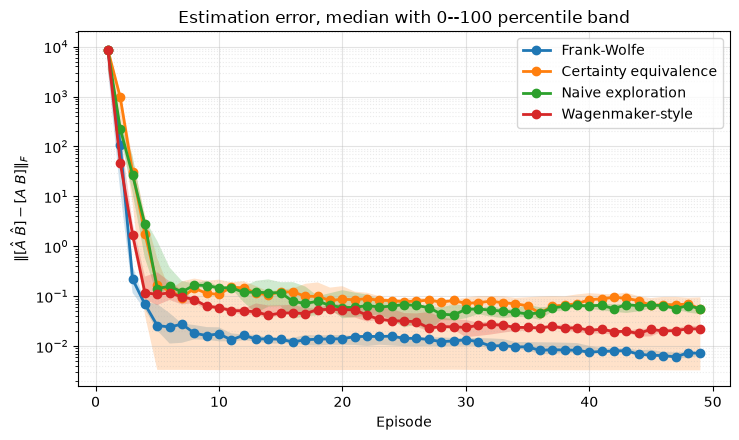

Saved TikZ figure to tikz_figures/system_id_cost_mc.tex


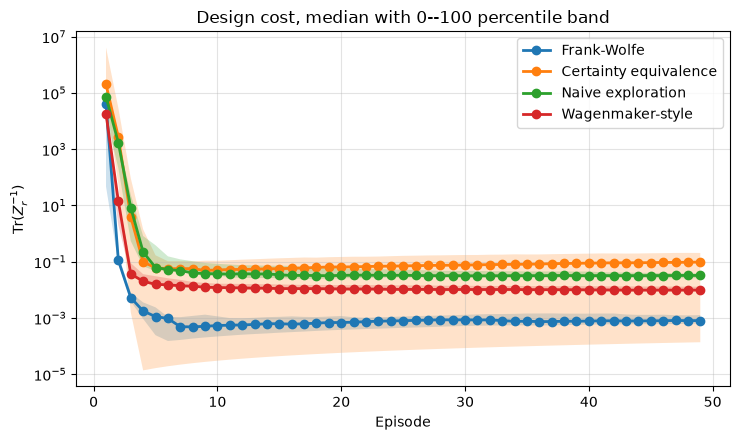

In [4]:
# -----------------------------
# Plot and export figures
# -----------------------------
# Wider percentile band for the shaded region.
lower_q = 0
upper_q = 100

episodes = np.arange(1, num_episodes)

plot_monte_carlo_bands(
    episodes,
    mc_results,
    quantity='errors',
    ylabel=r'$\|[\hat A\ \hat B]-[A\ B]\|_F$',
    title=f'Estimation error, median with {lower_q}--{upper_q} percentile band',
    lower_q=lower_q,
    upper_q=upper_q,
    log_scale=True,
    tikz_path='tikz_figures/system_id_error_mc.tex',
)

plot_monte_carlo_bands(
    episodes,
    mc_results,
    quantity='costs',
    ylabel=r'$\operatorname{Tr}(Z_r^{-1})$',
    title=f'Design cost, median with {lower_q}--{upper_q} percentile band',
    lower_q=lower_q,
    upper_q=upper_q,
    log_scale=True,
    tikz_path='tikz_figures/system_id_cost_mc.tex',
)